In [9]:
import sys
import sklearn
import tensorflow as tf
import pandas as pd
from tensorflow import keras
import numpy as np
import os
import allel

df_2023 = pd.read_csv('g2f_2023_phenotypic_clean_data.csv', encoding='latin-1')
df_2022 = pd.read_csv('g2f_2022_phenotypic_clean_data.csv', encoding='latin-1')
df_2021 = pd.read_csv('g2f_2021_phenotypic_clean_data.csv', encoding='latin-1')
df_2020 = pd.read_csv('g2f_2020_phenotypic_clean_data.csv', encoding='latin-1')
df_2019 = pd.read_csv('g2f_2019_phenotypic_clean_data.csv', encoding='latin-1')
weather_2023 = pd.read_csv('G2F_WeatherData_2023.csv')
weather_2022 = pd.read_csv('G2F_WeatherData_2022.csv')
weather_2021 = pd.read_csv('G2F_WeatherData_2021.csv')
weather_2020 = pd.read_csv('G2F_WeatherData_2020.csv')
weather_2019 = pd.read_csv('G2F_WeatherData_2019.csv')
weather_2018 = pd.read_csv('G2F_WeatherData_2018.csv')
weather_2017 = pd.read_csv('G2F_WeatherData_2017.csv')
weather_2016 = pd.read_csv('G2F_WeatherData_2016.csv')
weather_2015 = pd.read_csv('G2F_WeatherData_2015.csv')
weather_2014 = pd.read_csv('G2F_WeatherData_2014.csv')

weather_dict = {}
weather_dict['2014'] = weather_2014
weather_dict['2015'] = weather_2015
weather_dict['2016'] = weather_2016
weather_dict['2017'] = weather_2017
weather_dict['2018'] = weather_2018
weather_dict['2019'] = weather_2019
weather_dict['2020'] = weather_2020
weather_dict['2021'] = weather_2021
weather_dict['2022'] = weather_2022
weather_dict['2023'] = weather_2023


/var/folders/zw/qttxqty93qq2w6vtn3d1nwg80000gn/T/ipykernel_23489/682166993.py:10: DtypeWarning: Columns (0: Plot, 1: Pass) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv('g2f_2023_phenotypic_clean_data.csv', encoding='latin-1')
/var/folders/zw/qttxqty93qq2w6vtn3d1nwg80000gn/T/ipykernel_23489/682166993.py:12: DtypeWarning: Columns (0: Plot) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2021 = pd.read_csv('g2f_2021_phenotypic_clean_data.csv', encoding='latin-1')
/var/folders/zw/qttxqty93qq2w6vtn3d1nwg80000gn/T/ipykernel_23489/682166993.py:13: DtypeWarning: Columns (0: Pass, 1: Filler) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2020 = pd.read_csv('g2f_2020_phenotypic_clean_data.csv', encoding='latin-1')
/var/folders/zw/qttxqty93qq2w6vtn3d1nwg80000gn/T/ipykernel_23489/682166993.py:14: DtypeWarning: Columns (0: Filler [enter 'filler' or blank], 1: Possible subs, 2: Confirm

In [10]:
required_phenotypes = [
    'Stand Count [# of plants]',
    'Plant Height [cm]',
    'Ear Height [cm]',
    'Anthesis [days]',
    'Silking [days]',
    'Grain Yield (bu/A)'
]

def clean_phenotypicData(df):
    df['experiment'] = df['Field-Location'].apply(lambda x: str(x)[2:] if pd.notna(x) and len(str(x)) >= 3 else None)
    df_h1 = df[df['experiment'] == 'H1'].copy()
    initial_count = len(df_h1)
    df_clean = df_h1.dropna(subset=required_phenotypes).copy()
    removed_count = initial_count - len(df_clean)
    return df_clean

cleaned_dfs = []
for year, df in [('2023', df_2023), ('2022', df_2022), 
                 ('2021', df_2021), ('2020', df_2020), ('2019', df_2019)]:
    cleaned = clean_phenotypicData(df)
    cleaned['year'] = year
    cleaned_dfs.append(cleaned)

full_phenotypic_df = pd.concat(cleaned_dfs, ignore_index=True)

In [11]:
dailyWeather_list = []

for year, df in weather_dict.items(): 
    df_copy = df.copy()
    
    df_copy['datetime'] = pd.to_datetime(
        df_copy['Year'].astype(str) + '-' + 
        df_copy['Month'].astype(str).str.zfill(2) + '-' + 
        df_copy['Day'].astype(str).str.zfill(2) + ' ' + 
        df_copy['Time'],
        format='%Y-%m-%d %H:%M',
        errors='coerce'
    )
    df_copy['date'] = df_copy['datetime'].dt.date
    df_copy['Field-Location'] = df_copy['Experiment'].str[:2] + 'H1'
    
    temp_col = [col for col in df_copy.columns if 'Temperature' in col][0]
    humid_col = [col for col in df_copy.columns if 'Relative_Humidity' in col][0]
    solar_col = [col for col in df_copy.columns if 'Solar' in col][0]
    rain_col = [col for col in df_copy.columns if 'Rainfall' in col][0]
    wind_col = [col for col in df_copy.columns if 'Wind Gust' in col][0]
    for col in [temp_col, humid_col, solar_col, rain_col, wind_col]:
        df_copy[col] = pd.to_numeric(df_copy[col], errors='coerce')
    
    initial_rows = len(df_copy)
    df_copy = df_copy.dropna(subset=[temp_col, humid_col, solar_col, rain_col, wind_col])
    
    daily = df_copy.groupby(['Field-Location', 'date']).agg({
        temp_col: ['mean', 'max', 'min'],
        humid_col: 'mean',
        solar_col: ['sum', 'max'],
        rain_col: 'sum',
        wind_col: 'max'
    }).round(2)
    
    colsList = []

    for col in daily.columns.values:
        processed_col_name = '_'.join(col).strip()
        colsList.append(processed_col_name)
    daily.columns = colsList
    
    daily = daily.rename(columns={
        f'{temp_col}_mean': 'Temperature.C_mean',
        f'{temp_col}_max': 'Temperature.C_max',
        f'{temp_col}_min': 'Temperature.C_min',
        f'{humid_col}_mean': 'Relative_Humidity_perc_mean',
        f'{solar_col}_sum': 'Solar_Radiation_sum',
        f'{solar_col}_max': 'Solar_Radiation_max',
        f'{rain_col}_sum': 'Rainfall_mm_sum',
        f'{wind_col}_max': 'Wind_Gust_m_s_max'
    })
    
    daily = daily.reset_index()
    daily['year'] = year
    
    dailyWeather_list.append(daily)
weather_daily = pd.concat(dailyWeather_list, ignore_index=True)


In [12]:
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

vcf_file = "inbreds_G2F_2014-2023_437k.vcf"

full_phenotypic_df[['female_parent', 'male_parent']] = full_phenotypic_df['Pedigree'].str.split('/', expand=True)

female_parents_list = full_phenotypic_df['female_parent'].unique().tolist()
callset = allel.read_vcf(vcf_file, samples=female_parents_list, fields=['calldata/GT', 'variants/CHROM', 'variants/POS'])

genotypes = allel.GenotypeArray(callset['calldata/GT'])
snp_matrix = genotypes.to_n_alt().T

imputer = SimpleImputer(strategy='mean')
snp_matrix_imputed = imputer.fit_transform(snp_matrix)

selector = VarianceThreshold(threshold=0.01) 
snp_matrix_filtered = selector.fit_transform(snp_matrix_imputed)

pca = PCA(n_components=50)
snp_pca = pca.fit_transform(snp_matrix_filtered)

num_clusters = 15
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(snp_pca)

missing_samples = ['6046-BECKS', 'A639', 'AGRO NAUT', 'ARPA W22 (X17EA)', 'BAROS', 
                   'D54VC14 RIB', 'D54VC14RIB', 'DKC29_89RIB', 'DKC48_95RIB', 
                   'DKC49-72RIB', 'DKC57-23RIB', 'DKC62-08', 'DKC64-65 RIB', 
                   'DKC64-65RIB', 'DKC67-44', 'Dyna-Gro D54VC14 RIB', 'GEMN-0096_PHK76_0014', 
                   'KELITIAS', 'LH123HT', 'LOCAL_CHECK', 'LOCAL_CHECK_1', 'LOCAL_CHECK_2', 
                   'LOCAL_CHECK_3', 'LOCAL_CHECK_4', 'LOCAL_CHECK_5', 'MO44_PHW65_0011', 
                   'MO44_PHW65_0110', 'MO44_PHW65_0252', 'MO44_PHW65_0256', 'MO44_PHW65_0349', 
                   'NC368', 'PHG80xPHP02', 'PHN11_PHW65_0032', 'PHN11_PHW65_0094', 
                   'PHN11_PHW65_0109', 'PHN11_PHW65_0407', 'PHN11_PHW65_0505', 
                   'PHW65_MOG_0060', 'PHW65_MOG_0067', 'PHW65_MOG_0068', 'PHW65_MOG_0075', 
                   'PHW65_MOG_0115', 'PHW65_MOG_0119', 'PHW65_MOG_0124', 'PHW65_MOG_0140', 
                   'PHW65_MOG_0157', 'PHW65_MOG_0192', 'PHW65_MOG_0195', 'PHW65_MOG_0200', 
                   'PHW65_MOG_0206', 'PHW65_MOG_0221', 'PHW65_MOG_0241', 'PHW65_MOG_0359', 
                   'PHW65_MOG_0388', 'PHW65_MOG_0393', 'PHW65_MOG_0490', 'PHW65_MOG_0560', 
                   'PHW65_MOG_0651', 'PHW65_MOG_0675', 'PI197', 'Pioneer P1366AM', 
                   'RAFINIO', 'REDEAR', 'TEXTO', 'TX110', 'W10010_0270', 'W22-UNIFORM MU STRAIN']

if 'female_parents_list' not in dir():
    female_parents_list = full_phenotypic_df['female_parent'].unique().tolist()

loaded_samples = [s for s in female_parents_list if s not in missing_samples]

cluster_map = dict(zip(loaded_samples, clusters))
full_phenotypic_df['female_cluster'] = full_phenotypic_df['female_parent'].map(cluster_map)

/Users/carolinawheeler/venvs/CSE404-env/lib/python3.11/site-packages/allel/io/vcf_read.py:1621: UserWarning: some samples not found, will be ignored: '6046-BECKS', 'A639', 'AGRO NAUT', 'ARPA W22 (X17EA)', 'BAROS', 'D54VC14 RIB', 'D54VC14RIB', 'DKC29_89RIB', 'DKC48_95RIB', 'DKC49-72RIB', 'DKC57-23RIB', 'DKC62-08', 'DKC64-65 RIB', 'DKC64-65RIB', 'DKC67-44', 'Dyna-Gro D54VC14 RIB', 'GEMN-0096_PHK76_0014', 'KELITIAS', 'LH123HT', 'LOCAL_CHECK', 'LOCAL_CHECK_1', 'LOCAL_CHECK_2', 'LOCAL_CHECK_3', 'LOCAL_CHECK_4', 'LOCAL_CHECK_5', 'MO44_PHW65_0011', 'MO44_PHW65_0110', 'MO44_PHW65_0252', 'MO44_PHW65_0256', 'MO44_PHW65_0349', 'NC368', 'PHG80xPHP02', 'PHN11_PHW65_0032', 'PHN11_PHW65_0094', 'PHN11_PHW65_0109', 'PHN11_PHW65_0407', 'PHN11_PHW65_0505', 'PHW65_MOG_0060', 'PHW65_MOG_0067', 'PHW65_MOG_0068', 'PHW65_MOG_0075', 'PHW65_MOG_0115', 'PHW65_MOG_0119', 'PHW65_MOG_0124', 'PHW65_MOG_0140', 'PHW65_MOG_0157', 'PHW65_MOG_0192', 'PHW65_MOG_0195', 'PHW65_MOG_0200', 'PHW65_MOG_0206', 'PHW65_MOG_0221', 

In [23]:
import pickle
import numpy as np
import pandas as pd

full_phenotypic_df['planting_date'] = pd.to_datetime(full_phenotypic_df['Date Plot Planted [MM/DD/YY]'], format='mixed')
full_phenotypic_df['harvest_date'] = pd.to_datetime(full_phenotypic_df['Date Plot Harvested [MM/DD/YY]'], format='mixed')

valid_years = ['2015', '2019', '2020', '2021', '2022', '2023']
valid_df = full_phenotypic_df[full_phenotypic_df['year'].isin(valid_years)]

model_data = []
missing_weather = 0

def get_hybrid_weather(row, weather_daily):
    mask = (weather_daily['Field-Location'] == row['Field-Location']) & \
           (weather_daily['date'] >= row['planting_date'].date()) & \
           (weather_daily['date'] <= row['harvest_date'].date()) & \
           (weather_daily['year'] == row['year'])
    
    hybrid_weather = weather_daily[mask].copy()
    
    if len(hybrid_weather) == 0:
        return None
    
    hybrid_weather = hybrid_weather.sort_values('date')
    weather_values = hybrid_weather.drop(columns=['Field-Location', 'date', 'year']).values
    
    return weather_values

for idx, row in valid_df.iterrows():
    if idx > 0 and idx % 5000 == 0:
        print(f"Processed {idx}/{len(valid_df)} hybrids...")
    
    weather_seq = get_hybrid_weather(row, weather_daily)
    
    if weather_seq is None:
        missing_weather += 1
        continue
    
    model_data.append({
        'pedigree': row['Pedigree'],
        'male_parent': row['male_parent'],
        'female_parent': row['female_parent'],
        'female_cluster': int(row['female_cluster']) if pd.notna(row['female_cluster']) else -1,
        'plant_height': row['Plant Height [cm]'],
        'ear_height': row['Ear Height [cm]'],
        'anthesis': row['Anthesis [days]'],
        'silking': row['Silking [days]'],
        'stand_count': row['Stand Count [# of plants]'],
        'yield': row['Grain Yield (bu/A)'],
        'weather_sequence': weather_seq.astype(np.float32),
        'location': row['Field-Location'],
        'year': row['year']
    })

coverage = (len(model_data) / (len(model_data) + missing_weather)) * 100

with open('model_ready_data.pkl', 'wb') as f:
    pickle.dump(model_data, f)

baseline_records = []
for d in model_data:
    seq = d['weather_sequence']
    
    record = {
        'pedigree': d['pedigree'],
        'male_parent': d['male_parent'],
        'female_cluster': d['female_cluster'],
        'plant_height': d['plant_height'],
        'ear_height': d['ear_height'],
        'anthesis': d['anthesis'],
        'silking': d['silking'],
        'stand_count': d['stand_count'],
        'yield': d['yield'],
        'location': d['location'],
        'year': d['year'],
        'season_length': len(seq),
        
        'temp_mean_mean': seq[:, 0].mean(),
        'temp_mean_max': seq[:, 0].max(),
        'temp_mean_min': seq[:, 0].min(),
        'temp_max_mean': seq[:, 1].mean(),
        'temp_max_max': seq[:, 1].max(),
        'temp_min_mean': seq[:, 2].mean(),
        'temp_min_min': seq[:, 2].min(),
        'humidity_mean': seq[:, 3].mean(),
        'humidity_max': seq[:, 3].max(),
        'solar_sum_mean': seq[:, 4].mean(),
        'solar_sum_max': seq[:, 4].max(),
        'solar_sum_total': seq[:, 4].sum(),
        'solar_max_mean': seq[:, 5].mean(),
        'solar_max_max': seq[:, 5].max(),
        'rain_sum_mean': seq[:, 6].mean(),
        'rain_sum_max': seq[:, 6].max(),
        'rain_sum_total': seq[:, 6].sum(),
        'wind_max_mean': seq[:, 7].mean(),
        'wind_max_max': seq[:, 7].max(),
    }
    baseline_records.append(record)

baseline_df = pd.DataFrame(baseline_records)
baseline_df.to_csv('baseline_data.csv', index=False)

print(f"Saved baseline_data.csv | Shape: {baseline_df.shape}")

Processed 5000/39469 hybrids...
Processed 10000/39469 hybrids...
Processed 15000/39469 hybrids...
Processed 20000/39469 hybrids...
Processed 25000/39469 hybrids...
Processed 30000/39469 hybrids...
Processed 35000/39469 hybrids...
Saved baseline_data.csv | Shape: (22667, 31)


In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

baseline_df = pd.read_csv('baseline_data.csv')
baseline_df = baseline_df.dropna()
print(f"Loaded {len(baseline_df)} records after dropping NAs")

Loaded 22405 records after dropping NAs


In [25]:
target = 'yield'
features = [col for col in baseline_df.columns if col not in ['pedigree', 'yield', 'location', 'year']]

X = baseline_df[features].copy()
y = baseline_df[target].copy()

le_male = LabelEncoder()
X['male_parent_encoded'] = le_male.fit_transform(X['male_parent'])
X['female_cluster'] = X['female_cluster'].astype(int)
X = X.drop(columns=['male_parent'])

print(f"Feature matrix: {X.shape} | Features: {X.columns.tolist()}")

Feature matrix: (22405, 27) | Features: ['female_cluster', 'plant_height', 'ear_height', 'anthesis', 'silking', 'stand_count', 'season_length', 'temp_mean_mean', 'temp_mean_max', 'temp_mean_min', 'temp_max_mean', 'temp_max_max', 'temp_min_mean', 'temp_min_min', 'humidity_mean', 'humidity_max', 'solar_sum_mean', 'solar_sum_max', 'solar_sum_total', 'solar_max_mean', 'solar_max_max', 'rain_sum_mean', 'rain_sum_max', 'rain_sum_total', 'wind_max_mean', 'wind_max_max', 'male_parent_encoded']


In [26]:
baseline_df = pd.read_csv('baseline_data_corrected.csv')

target = 'yield'
features = [col for col in baseline_df.columns if col not in ['pedigree', 'yield', 'location']]

X = baseline_df[features].copy()
y = baseline_df[target].copy()

le_male = LabelEncoder()
X['male_parent_encoded'] = le_male.fit_transform(X['male_parent'])
X['female_cluster'] = X['female_cluster'].astype(int)
X = X.drop(columns=['male_parent'])

train_years = [2019, 2020, 2021]
test_years = [2022, 2023]

train_idx = baseline_df['year'].isin(train_years)
test_idx = baseline_df['year'].isin(test_years)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(X_train)} samples {train_years} | Test: {len(X_test)} samples {test_years}")

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

Train: 12896 samples [2019, 2020, 2021] | Test: 9771 samples [2022, 2023]


In [27]:
# baseline model 1: Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train_scaled, y_train)
y_pred_lr = linear_reg.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression | RMSE: {rmse_lr:.2f}  MAE: {mae_lr:.2f}  R2: {r2_lr:.4f}")

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': linear_reg.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df.head(10))

print(f"Yield | mean: {y.mean():.2f}  std: {y.std():.2f}  min: {y.min():.2f}  max: {y.max():.2f}")

correlations = pd.DataFrame({
    'feature': X.columns,
    'correlation': [X[col].corr(y) for col in X.columns]
}).sort_values('correlation', ascending=False)

print(correlations.head(10))

Linear Regression | RMSE: 312.88  MAE: 204.38  R2: -23.7536
           feature  coefficient
8   temp_mean_mean  -462.584897
11   temp_max_mean   382.282387
13   temp_min_mean   236.410484
20  solar_max_mean  -233.119129
21   solar_max_max   226.126009
14    temp_min_min  -112.732815
18   solar_sum_max  -102.641736
26    wind_max_max    80.419948
10   temp_mean_min    73.976130
25   wind_max_mean   -70.651094
Yield | mean: 151.76  std: 55.08  min: 7.90  max: 299.83
                feature  correlation
1          plant_height     0.388917
2            ear_height     0.335932
5           stand_count     0.226453
27  male_parent_encoded     0.131580
3              anthesis     0.083418
4               silking     0.065810
14         temp_min_min     0.038250
0        female_cluster     0.017945
10        temp_mean_min     0.014329
21        solar_max_max     0.004144


In [28]:
# baseline model 2: Ridge Regression
alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge (alpha={ridge.alpha_:.1f}) | RMSE: {rmse_ridge:.2f}  MAE: {mae_ridge:.2f}  R2: {r2_ridge:.4f}")

ridge_coef = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': ridge.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(ridge_coef.head(10))

Ridge (alpha=1000.0) | RMSE: 71.29  MAE: 57.34  R2: -0.2851
            feature  coefficient
26     wind_max_max    24.295624
25    wind_max_mean   -16.248272
10    temp_mean_min    14.847591
5       stand_count    13.395148
21    solar_max_max     9.944133
19  solar_sum_total    -9.552569
2        ear_height     8.556863
22    rain_sum_mean     7.486389
14     temp_min_min     6.693987
1      plant_height     6.225804


In [29]:
#baseline model 3: SVM
from sklearn.svm import SVR
svm = SVR(kernel='rbf', C=100, gamma='scale')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
rmse_svm = np.sqrt(mean_squared_error(y_test, y_pred_svm))
mae_svm = mean_absolute_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

In [30]:

import pickle
import numpy as np
import tensorflow as tf
import random 
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

with open('model_ready_data.pkl', 'rb') as f:
    model_data = pickle.load(f)

#get vanraden G matrix from SNP data
def create_genomic_relationship_matrix(snp_matrix):

    p = snp_matrix.mean(axis=0) / 2  
    M = snp_matrix - 2 * p  
    
    G = np.dot(M, M.T) / (2 * np.sum(p * (1 - p)))
    
    return G

#try using PCA to get continuous primary component scores instead of just clusters?
def get_pca_features_from_snps(snp_matrix, n_components=20):
    pca = PCA(n_components=n_components)
    snp_pcs = pca.fit_transform(snp_matrix)
    
    print(f"Explained variance by top {n_components} PCs: {pca.explained_variance_ratio_.sum():.3f}")
    
    return snp_pcs, pca


female_pcs, pca = get_pca_features_from_snps(snp_matrix, n_components=20)

#map mom to primary component scores
female_to_pcs = dict(zip(female_parents_list, female_pcs))

#replace female_cluster with PC features
for i, d in enumerate(model_data):
    female_name = d['female_parent']
    if female_name in female_to_pcs:
        d['female_pcs'] = female_to_pcs[female_name]
    else:
        d['female_pcs'] = female_pcs.mean(axis=0)

G_matrix = create_genomic_relationship_matrix(snp_matrix)



weather_sequences = []
male_parents = []
female_clusters = []
phenotypes = []
yields = []
years = []
locations = []

for d in model_data:
    weather_sequences.append(d['weather_sequence'])
    male_parents.append(d['male_parent'])
    female_clusters.append(d['female_cluster'])
    phenotypes.append([
        d['plant_height'],
        d['ear_height'],
        d['anthesis'],
        d['silking'],
        d['stand_count']
    ])
    yields.append(d['yield'])
    years.append(d['year'])
    locations.append(d['location'])

X_weather = weather_sequences
X_male = np.array(male_parents)
X_female = np.array(female_clusters)
X_pheno = np.array(phenotypes)
y = np.array(yields)

lengths = [len(seq) for seq in X_weather]

years = np.array([int(y) for y in years])

train_mask = (years >= 2019) & (years <= 2021)
test_mask = (years >= 2022) & (years <= 2023)

X_weather_train = [X_weather[i] for i in range(len(X_weather)) if train_mask[i]]
X_weather_test = [X_weather[i] for i in range(len(X_weather)) if test_mask[i]]

X_male_train = X_male[train_mask]
X_male_test = X_male[test_mask]

X_female_train = X_female[train_mask]
X_female_test = X_female[test_mask]

X_pheno_train = X_pheno[train_mask]
X_pheno_test = X_pheno[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

Explained variance by top 20 PCs: 0.413


In [31]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(lengths)

X_weather_train_padded = pad_sequences(X_weather_train, maxlen=max_len, dtype='float32', padding='post', truncating='post')
X_weather_test_padded = pad_sequences(X_weather_test, maxlen=max_len, dtype='float32', padding='post', truncating='post')

train_mask = (X_weather_train_padded.sum(axis=2) != 0).astype(float)
test_mask = (X_weather_test_padded.sum(axis=2) != 0).astype(float)

weather_full = [d['weather_sequence'] for d in model_data]
male_full = np.array([d['male_parent'] for d in model_data])
female_full = np.array([d['female_cluster'] for d in model_data])
pheno_full = np.array([[d['plant_height'], d['ear_height'], d['anthesis'], 
                        d['silking'], d['stand_count']] for d in model_data])
y_full = np.array([d['yield'] for d in model_data])

weather_padded_full = pad_sequences(weather_full, maxlen=192, dtype='float32', padding='post', truncating='post')

male_encoder_full = LabelEncoder()
male_enc_full = male_encoder_full.fit_transform(male_full)

female_enc_full = female_full.astype(int)

pheno_scaler_full = StandardScaler()
pheno_scaled_full = pheno_scaler_full.fit_transform(pheno_full)

years_full = np.array([int(d['year']) for d in model_data])
train_mask = (years_full >= 2019) & (years_full <= 2021)
test_mask = (years_full >= 2022) & (years_full <= 2023)

X_weather_train = weather_padded_full[train_mask]
X_weather_test = weather_padded_full[test_mask]
X_male_train = male_enc_full[train_mask]
X_male_test = male_enc_full[test_mask]
X_female_train = female_enc_full[train_mask]
X_female_test = female_enc_full[test_mask]
X_pheno_train = pheno_scaled_full[train_mask]
X_pheno_test = pheno_scaled_full[test_mask]
y_train = y_full[train_mask]
y_test = y_full[test_mask]

In [33]:
#add growing degree days as a derived feature maybe more meaningful less overfitting
def add_gdd_to_weather_array(X_weather_padded):
    t_max = X_weather_padded[:, :, 1]  
    t_min = X_weather_padded[:, :, 2] 
    
    t_avg = (t_max + t_min) / 2
    daily_gdd = np.maximum(0, t_avg - 10)  
    daily_gdd = np.minimum(daily_gdd, 20) 
    
    cum_gdd = np.cumsum(daily_gdd, axis=1)
    cum_gdd = cum_gdd.reshape(cum_gdd.shape[0], cum_gdd.shape[1], 1)
    
    X_weather_gdd = np.concatenate([X_weather_padded, cum_gdd], axis=2)
    
    return X_weather_gdd

X_weather_train_gdd = add_gdd_to_weather_array(X_weather_train_padded)
X_weather_test_gdd = add_gdd_to_weather_array(X_weather_test_padded)


Train shape: (12896, 192, 9)
Test shape: (9771, 192, 9)


In [35]:
# try grouping females by primary components instead of just snp clustering
def create_model_with_pcs(sequence_length, n_weather_features, n_male, n_pheno, n_pcs=20):
    
    weather_in = layers.Input(shape=(sequence_length, n_weather_features), name='weather')
    x = layers.Masking(mask_value=0.)(weather_in)
    x = layers.LSTM(64, return_sequences=True, dropout=0.3)(x)
    x = layers.LSTM(32, dropout=0.3)(x)
    weather_out = layers.Dense(16, activation='relu')(x)
    
    male_in = layers.Input(shape=(1,), name='male')
    male_emb = layers.Embedding(n_male, 16)(male_in)
    male_flat = layers.Flatten()(male_emb)
    
    female_pcs_in = layers.Input(shape=(n_pcs,), name='female_pcs')
    
    pheno_in = layers.Input(shape=(n_pheno,), name='phenotypes')
  
    concat = layers.Concatenate()([weather_out, male_flat, female_pcs_in, pheno_in])
    x = layers.Dense(64, activation='relu')(concat)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1)(x)
    
    model = Model(
        inputs=[weather_in, male_in, female_pcs_in, pheno_in],
        outputs=out
    )
    
    return model

X_female_pcs_train = np.array([d['female_pcs'] for i, d in enumerate(model_data) if train_mask[i]])
X_female_pcs_test = np.array([d['female_pcs'] for i, d in enumerate(model_data) if test_mask[i]])


In [42]:

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)



# try adding with growing degree day features 
n_weather_features_gdd = X_weather_train_gdd[0].shape[1]  

from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = X_weather_train_gdd.shape[1]  
print(f"Sequence length: {max_len}")

X_weather_train_padded = X_weather_train_gdd
X_weather_test_padded = X_weather_test_gdd

model = create_model_with_pcs(
    sequence_length=max_len,
    n_weather_features=n_weather_features_gdd,
    n_male=len(np.unique(X_male_train)),
    n_pheno=5,
    n_pcs=20
)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])


early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# train
history = model.fit(
    [X_weather_train_padded, X_male_train.reshape(-1,1), X_female_pcs_train, X_pheno_train],
    y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

# eval
y_pred = model.predict([X_weather_test_padded, X_male_test.reshape(-1,1), X_female_pcs_test, X_pheno_test]).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"LSTM with GDD + PC features:")
print(f"RMSE: {rmse:.2f} bu/ac")
print(f"R²: {r2:.4f}")

Sequence length: 192
Train shape: (12896, 192, 9)
Test shape: (9771, 192, 9)
Epoch 1/50


2026-04-12 19:26:21.823275: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


323/323 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - loss: 24751.6719 - mae: 149.4724 - val_loss: 19500.9414 - val_mae: 126.5085
Epoch 2/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 18321.2266 - mae: 117.7428 - val_loss: 12246.6396 - val_mae: 97.2118
Epoch 3/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 14409.9961 - mae: 99.4957 - val_loss: 9777.8477 - val_mae: 86.6867
Epoch 4/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 10227.3633 - mae: 84.0912 - val_loss: 8495.7666 - val_mae: 80.9842
Epoch 5/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 7592.9165 - mae: 72.4161 - val_loss: 7103.7046 - val_mae: 74.1838
Epoch 6/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 6274.9258 - mae: 65.0285 - val_loss: 6278.8301 - val_mae: 69.7203
Epoch 7/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 5494.8911 - mae: 60.2530 - val_loss: 5523.1743 - val_mae: 65.1325
Epoch 8/50
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 4979.7017 - mae: 56.8380 - val_loss: 5049.68

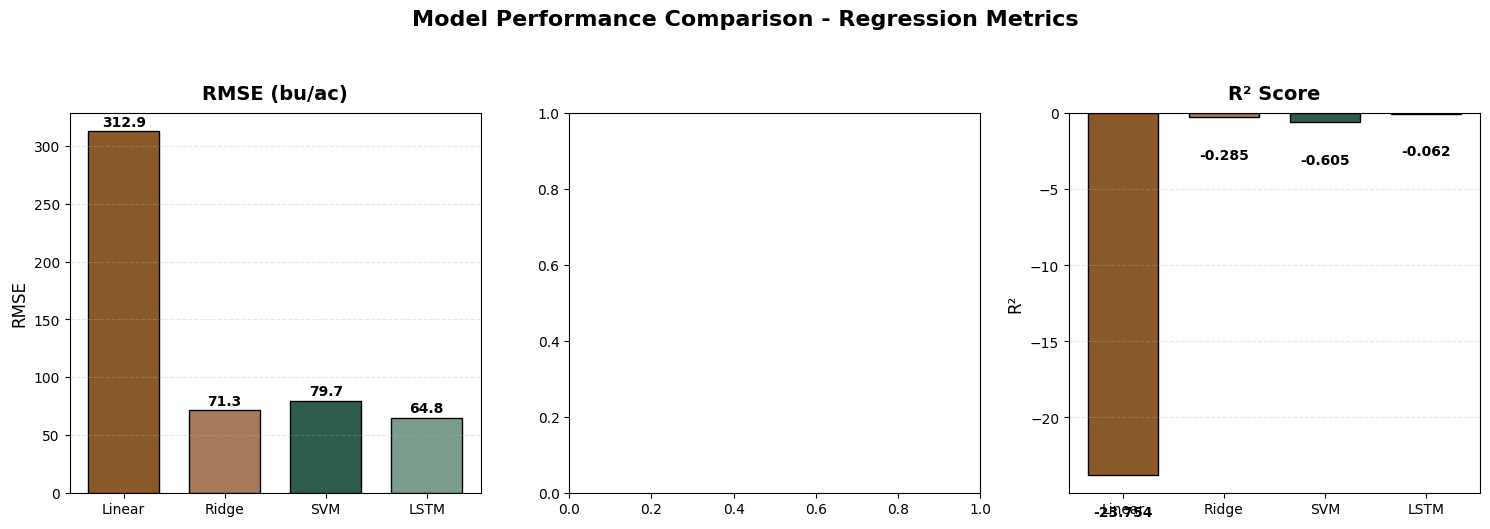

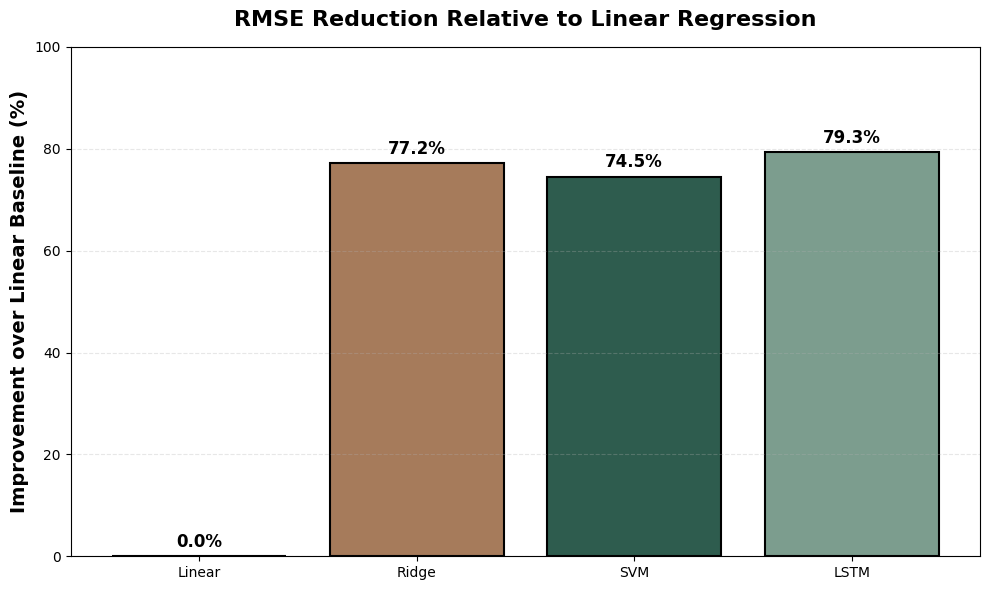

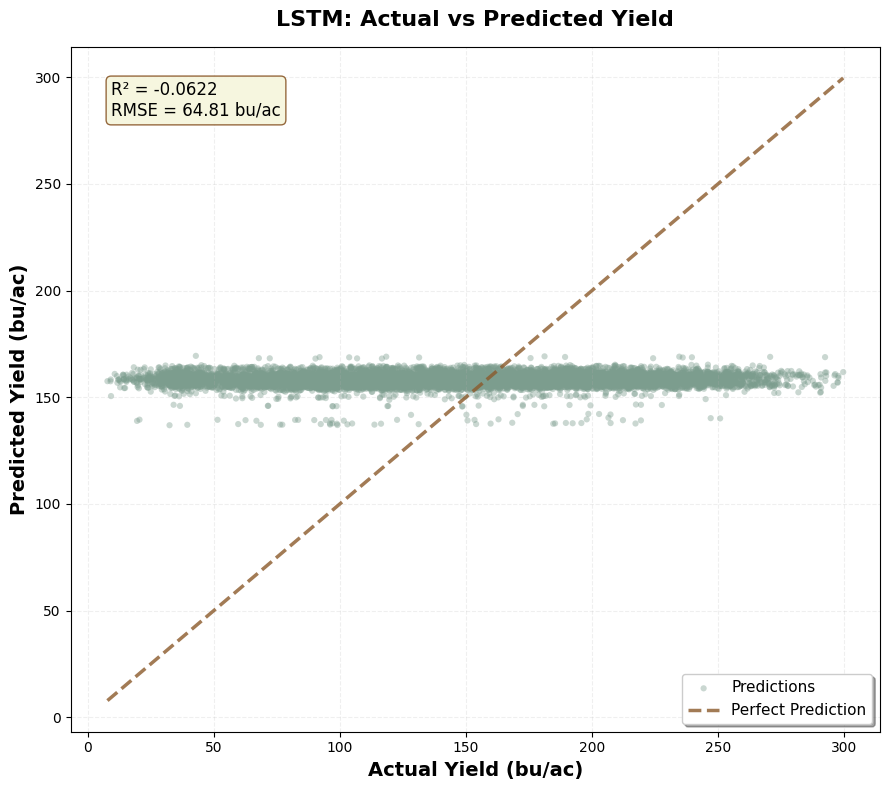

NameError: name 'mae' is not defined

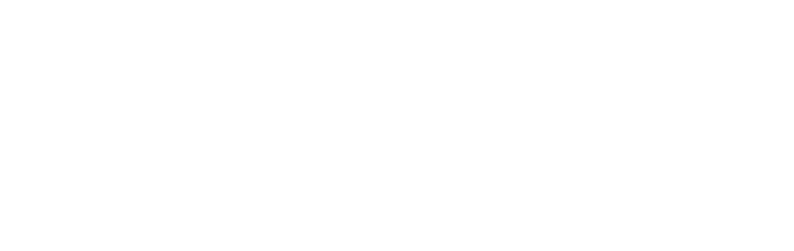

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#makin performance metric graphs woohoo

colors = ['#8B5A2B', '#A67B5B', '#2E5C4E', '#7C9D8E']

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'SVM', 'LSTM'],
    'RMSE': [rmse_lr, rmse_ridge, rmse_svm, rmse],
    'R2': [r2_lr, r2_ridge, r2_svm, r2]
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_short = ['Linear', 'Ridge', 'SVM', 'LSTM']
x = np.arange(len(models_short))
width = 0.7

bars1 = axes[0].bar(x, results['RMSE'], width, color=colors, edgecolor='black', linewidth=1)
axes[0].set_title('RMSE (bu/ac)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_short)
axes[0].grid(True, alpha=0.3, axis='y', linestyle='--')
for bar, val in zip(bars1, results['RMSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.1f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')


bars3 = axes[2].bar(x, results['R2'], width, color=colors, edgecolor='black', linewidth=1)
axes[2].set_title('R² Score', fontsize=14, fontweight='bold', pad=10)
axes[2].set_ylabel('R²', fontsize=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels(models_short)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
axes[2].grid(True, alpha=0.3, axis='y', linestyle='--')
for bar, val in zip(bars3, results['R2']):
    if val < 0:
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2, f'{val:.3f}', 
                    ha='center', va='top', fontsize=10, fontweight='bold')
    else:
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison - Regression Metrics', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('figure1_regression_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

improvement = [0, ((rmse_lr - rmse_ridge)/rmse_lr)*100, ((rmse_lr - rmse_svm)/rmse_lr)*100, ((rmse_lr - rmse)/rmse_lr)*100]

bars = ax.bar(models_short, improvement, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Improvement over Linear Baseline (%)', fontsize=14, fontweight='bold')
ax.set_title('RMSE Reduction Relative to Linear Regression', fontsize=16, fontweight='bold', pad=15)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

for bar, val in zip(bars, improvement):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figure2_improvement.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

if 'y_test' in locals() and 'y_pred' in locals():
    fig, ax = plt.subplots(figsize=(9, 8))
    
    ax.scatter(y_test, y_pred, alpha=0.4, c=colors[3], s=20, edgecolors='none', label='Predictions')
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], '--', color=colors[0], linewidth=2.5, 
            label='Perfect Prediction', alpha=0.8)
    
    ax.set_xlabel('Actual Yield (bu/ac)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Predicted Yield (bu/ac)', fontsize=14, fontweight='bold')
    ax.set_title('LSTM: Actual vs Predicted Yield', fontsize=16, fontweight='bold', pad=15)
    ax.legend(loc='lower right', fontsize=11, frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.2, linestyle='--')
    
    textstr = f'R² = {r2:.4f}\nRMSE = {rmse:.2f} bu/ac'
    props = dict(boxstyle='round', facecolor='#F5F5DC', alpha=0.9, edgecolor=colors[0])
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.savefig('figure3_lstm_scatter.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')

table_data = [
    ['Model', 'RMSE', 'MAE', 'R²', 'vs. Baseline'],
    ['Linear Regression', f'{rmse_lr:.1f}', f'{mae_lr:.1f}', f'{r2_lr:.3f}', '—'],
    ['Ridge Regression', f'{rmse_ridge:.1f}', f'{mae_ridge:.1f}', f'{r2_ridge:.3f}', f'{(rmse_lr-rmse_ridge)/rmse_lr*100:.1f}%'],
    ['SVM', f'{rmse_svm:.1f}', f'{mae_svm:.1f}', f'{r2_svm:.3f}', f'{(rmse_lr-rmse_svm)/rmse_lr*100:.1f}%'],
    ['LSTM (Ours)', f'{rmse:.1f}', f'{mae:.1f}', f'{r2:.4f}', f'{(rmse_lr-rmse)/rmse_lr*100:.1f}%']
]

table = ax.table(cellText=table_data, loc='center', cellLoc='center', 
                 colWidths=[0.2, 0.12, 0.12, 0.12, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_facecolor(colors[0])
        cell.set_text_props(weight='bold', color='white')
    elif i % 2 == 1:
        cell.set_facecolor('#F5F5DC')
    cell.set_edgecolor(colors[1])
    cell.set_linewidth(0.5)

plt.suptitle('Table 1: Model Performance Summary', fontsize=14, fontweight='bold', y=0.95)
plt.savefig('figure4_results_table.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


Unique locations: 15
Unique years: 5
Train samples: 12896
Test samples: 9771


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ weather             │ (None, 192, 8)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 192, 8)    │          0 │ weather[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 192, 8)    │          0 │ weather[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 192)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 192, 64)   │     18,688 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ male (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ female (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ location            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ year (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ lstm[0][0],       │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 8)      │        216 │ male[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 8)      │        120 │ female[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 2)      │         30 │ location[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 2)      │         10 │ year[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weather_features    │ (None, 32)        │      1,056 │ lstm_1[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2)         │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2)         │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phenotypes          │ (None, 5)         │          0 │ -               

 Total params: 38,617 (150.85 KB)

 Trainable params: 38,489 (150.35 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - loss: 24984.0859 - mae: 150.0745 - val_loss: 22152.4785 - val_mae: 143.7781
Epoch 2/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - loss: 20958.4961 - mae: 126.6671 - val_loss: 15886.5195 - val_mae: 119.3168
Epoch 3/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - loss: 17170.5020 - mae: 110.9824 - val_loss: 11742.4834 - val_mae: 100.4328
Epoch 4/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - loss: 13736.6543 - mae: 99.6731 - val_loss: 10353.5664 - val_mae: 93.1380
Epoch 5/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - loss: 11494.1387 - mae: 91.2101 - val_loss: 8207.5391 - val_mae: 81.7418
Epoch 6/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - loss: 10021.1562 - mae: 84.4186 - val_loss: 7008.7207 - val_mae: 73.9665
Epoch 7/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - loss: 8579.9932 - mae: 76.8748 - val_loss: 5523.4014 - val_mae: 64.5740
Epoch 8/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - loss: 7407.2734 - mae: 7

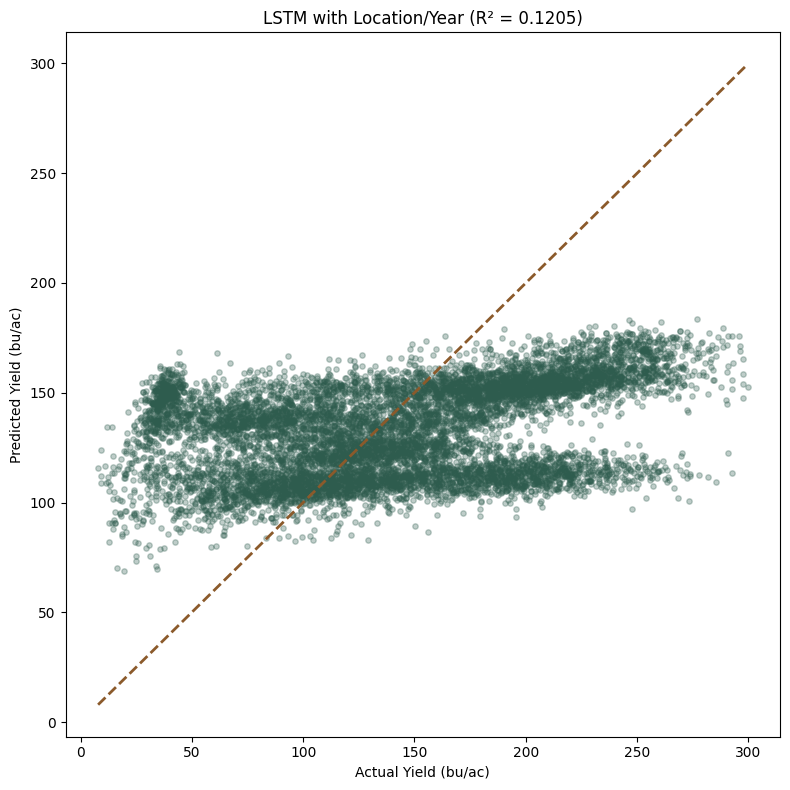

In [45]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

tf.keras.backend.clear_session()

np.random.seed(42)
tf.random.set_seed(42)

# encode locs and years
location_encoder = LabelEncoder()
year_encoder = LabelEncoder()

locations_full = [d['location'] for d in model_data]
years_full = np.array([int(d['year']) for d in model_data])

location_encoded = location_encoder.fit_transform(locations_full)
year_encoded = year_encoder.fit_transform(years_full)

n_locations = len(location_encoder.classes_)
n_years = len(year_encoder.classes_)

print(f"Unique locations: {n_locations}")
print(f"Unique years: {n_years}")

# make train/test masks
train_mask = (years_full >= 2019) & (years_full <= 2021)
test_mask = (years_full >= 2022) & (years_full <= 2023)

# split data
X_weather_train = weather_padded_full[train_mask]
X_weather_test = weather_padded_full[test_mask]
X_male_train = male_enc_full[train_mask]
X_male_test = male_enc_full[test_mask]
X_female_train = female_enc_full[train_mask]
X_female_test = female_enc_full[test_mask]
X_pheno_train = pheno_scaled_full[train_mask]
X_pheno_test = pheno_scaled_full[test_mask]
location_train = location_encoded[train_mask]
location_test = location_encoded[test_mask]
year_train = year_encoded[train_mask]
year_test = year_encoded[test_mask]
y_train = y_full[train_mask]
y_test = y_full[test_mask]

print(f"Train samples: {len(X_weather_train)}")
print(f"Test samples: {len(X_weather_test)}")


# try adding more regularization to curb overfitting
def create_regularized_model(sequence_length, n_weather_features, n_male, n_female, n_pheno, n_locations, n_years):
    
    weather_in = layers.Input(shape=(sequence_length, n_weather_features), name='weather')
    x = layers.Masking(mask_value=0.)(weather_in)
    x = layers.LSTM(64, return_sequences=True, dropout=0.3)(x)
    x = layers.LSTM(32, dropout=0.3)(x)
    weather_out = layers.Dense(32, activation='relu', name='weather_features')(x)
    
    male_in = layers.Input(shape=(1,), name='male')
    male_emb = layers.Embedding(n_male, 8)(male_in)
    male_flat = layers.Flatten()(male_emb)
    
    female_in = layers.Input(shape=(1,), name='female')
    female_emb = layers.Embedding(n_female, 8)(female_in)
    female_flat = layers.Flatten()(female_emb)
    
    location_in = layers.Input(shape=(1,), name='location')
    location_emb = layers.Embedding(n_locations, 2)(location_in)
    location_flat = layers.Flatten()(location_emb)
    
    year_in = layers.Input(shape=(1,), name='year')
    year_emb = layers.Embedding(n_years, 2)(year_in)
    year_flat = layers.Flatten()(year_emb)
    
    pheno_in = layers.Input(shape=(n_pheno,), name='phenotypes')
    
    concat = layers.Concatenate()([weather_out, male_flat, female_flat, location_flat, year_flat, pheno_in])
    
    x = layers.Dense(64, activation='relu')(concat)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, name='yield')(x)
    
    model = Model(
        inputs=[weather_in, male_in, female_in, location_in, year_in, pheno_in],
        outputs=out
    )
    
    return model

model = create_regularized_model(
    sequence_length=192,
    n_weather_features=8,
    n_male=len(np.unique(X_male_train)),
    n_female=15,
    n_pheno=5,
    n_locations=n_locations,
    n_years=n_years
)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    [X_weather_train, X_male_train.reshape(-1,1), X_female_train.reshape(-1,1),
     location_train.reshape(-1,1), year_train.reshape(-1,1), X_pheno_train],
    y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)

y_pred = model.predict(
    [X_weather_test, X_male_test.reshape(-1,1), X_female_test.reshape(-1,1),
     location_test.reshape(-1,1), year_test.reshape(-1,1), X_pheno_test]
).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n model results:")
print(f"RMSE: {rmse:.2f} bu/ac")
print(f"R²: {r2:.4f}")

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.3, c='#2E5C4E', s=15)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], '--', color='#8B5A2B', linewidth=2)
ax.set_xlabel('Actual Yield (bu/ac)')
ax.set_ylabel('Predicted Yield (bu/ac)')
ax.set_title(f'LSTM with Location/Year (R² = {r2:.4f})')
plt.tight_layout()
plt.show()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ weather             │ (None, 192, 8)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 192, 8)    │          0 │ weather[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ male (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ female (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 192, 8)    │          0 │ weather[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 192)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 8)      │        216 │ male[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 8)      │        120 │ female[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 192, 64)   │     18,688 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ lstm[0][0],       │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phenotypes          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weather_features    │ (None, 16)        │        528 │ lstm_1[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         96 │ phenotypes[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        272 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ location            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ year (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16)        │          0 │ weather_features

 Total params: 43,321 (169.22 KB)

 Trainable params: 43,193 (168.72 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - loss: 25445.4102 - mae: 151.7225 - val_loss: 22545.3223 - val_mae: 142.6162
Epoch 2/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - loss: 20429.0879 - mae: 127.8667 - val_loss: 14622.4912 - val_mae: 115.6599
Epoch 3/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 38s 117ms/step - loss: 15589.1582 - mae: 107.8407 - val_loss: 10419.2227 - val_mae: 95.6768
Epoch 4/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 38s 117ms/step - loss: 11519.7871 - mae: 90.8323 - val_loss: 8106.4619 - val_mae: 83.4655
Epoch 5/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - loss: 8905.1699 - mae: 77.6787 - val_loss: 6268.3076 - val_mae: 71.7686
Epoch 6/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 39s 119ms/step - loss: 7583.7939 - mae: 70.6097 - val_loss: 5662.5459 - val_mae: 67.5292
Epoch 7/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 39s 120ms/step - loss: 6325.9097 - mae: 63.4568 - val_loss: 4090.6887 - val_mae: 56.2840
Epoch 8/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - loss: 5627.3506 - ma

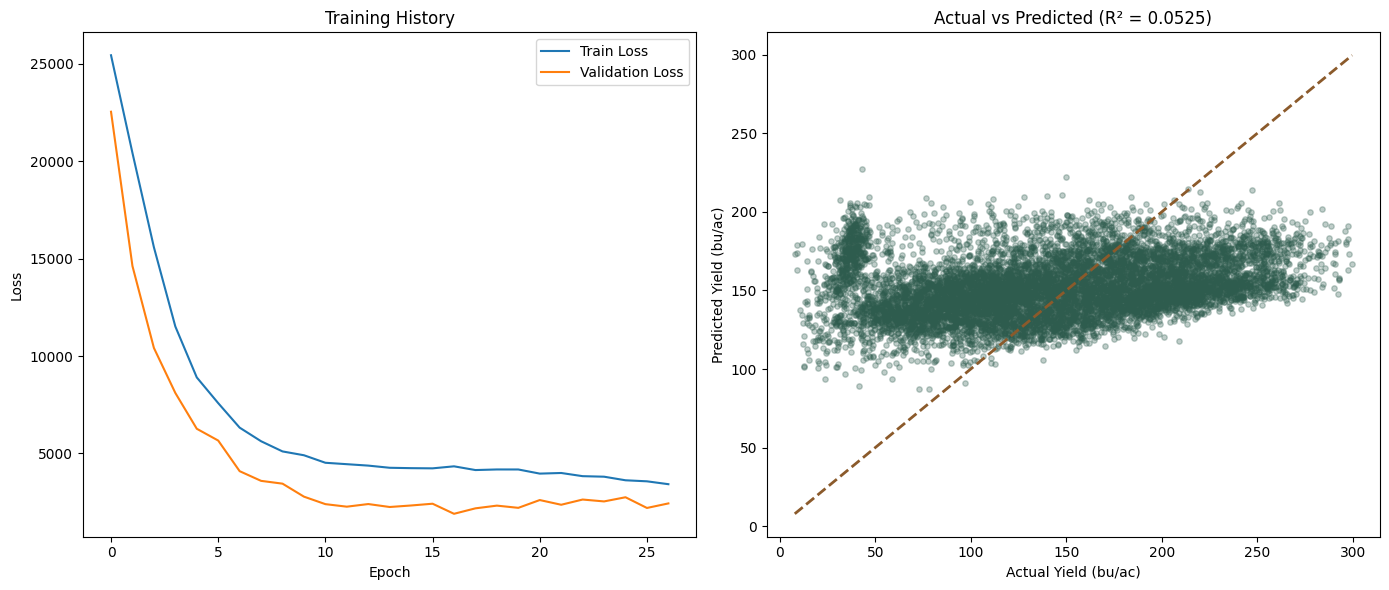


Model Comparison:
               Model       RMSE        R²
0      Previous LSTM  58.600000  0.131500
1  Interaction Model  61.213584  0.052499


In [49]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)


# try forcing interaction between weather and pheno
def create_interaction_model(sequence_length, n_weather_features, n_male, n_female, n_pheno, n_locations, n_years):
    
    weather_in = layers.Input(shape=(sequence_length, n_weather_features), name='weather')
    x = layers.Masking(mask_value=0.)(weather_in)
    x = layers.LSTM(64, return_sequences=True, dropout=0.3)(x)
    x = layers.LSTM(32, dropout=0.3)(x)
    weather_out = layers.Dense(16, activation='relu', name='weather_features')(x)
    
    male_in = layers.Input(shape=(1,), name='male')
    male_emb = layers.Embedding(n_male, 8)(male_in)
    male_flat = layers.Flatten()(male_emb)
    
    female_in = layers.Input(shape=(1,), name='female')
    female_emb = layers.Embedding(n_female, 8)(female_in)
    female_flat = layers.Flatten()(female_emb)
    
    location_in = layers.Input(shape=(1,), name='location')
    location_emb = layers.Embedding(n_locations, 2)(location_in)
    location_flat = layers.Flatten()(location_emb)
    
    year_in = layers.Input(shape=(1,), name='year')
    year_emb = layers.Embedding(n_years, 2)(year_in)
    year_flat = layers.Flatten()(year_emb)
    
    pheno_in = layers.Input(shape=(n_pheno,), name='phenotypes')
    pheno_dense = layers.Dense(16, activation='relu')(pheno_in)
    
    weather_pheno_interact = layers.Multiply()([weather_out, pheno_dense])
    weather_pheno_interact = layers.Dense(32, activation='relu')(weather_pheno_interact)
    
    genetic = layers.Concatenate()([male_flat, female_flat])
    genetic_dense = layers.Dense(16, activation='relu')(genetic)
    weather_genetic_interact = layers.Multiply()([weather_out, genetic_dense])
    weather_genetic_interact = layers.Dense(32, activation='relu')(weather_genetic_interact)
    
    concat = layers.Concatenate()([
        weather_out, 
        weather_pheno_interact,
        weather_genetic_interact,
        pheno_dense,
        genetic_dense,
        location_flat, 
        year_flat
    ])
    
    x = layers.Dense(64, activation='relu')(concat)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, name='yield')(x)
    
    model = Model(
        inputs=[weather_in, male_in, female_in, location_in, year_in, pheno_in],
        outputs=out
    )
    return model

model = create_interaction_model(
    sequence_length=192,
    n_weather_features=8,
    n_male=len(np.unique(X_male_train)),
    n_female=15,
    n_pheno=5,
    n_locations=n_locations,
    n_years=n_years
)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

history = model.fit(
    [X_weather_train, X_male_train.reshape(-1,1), X_female_train.reshape(-1,1),
     location_train.reshape(-1,1), year_train.reshape(-1,1), X_pheno_train],
    y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)

y_pred = model.predict(
    [X_weather_test, X_male_test.reshape(-1,1), X_female_test.reshape(-1,1),
     location_test.reshape(-1,1), year_test.reshape(-1,1), X_pheno_test]
).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print("interaction model results")
print(f"RMSE: {rmse:.2f} bu/ac")
print(f"R²: {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training History')
axes[0].legend()

axes[1].scatter(y_test, y_pred, alpha=0.3, c='#2E5C4E', s=15)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], '--', color='#8B5A2B', linewidth=2)
axes[1].set_xlabel('Actual Yield (bu/ac)')
axes[1].set_ylabel('Predicted Yield (bu/ac)')
axes[1].set_title(f'Actual vs Predicted (R² = {r2:.4f})')

plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'Model': ['Previous LSTM', 'Interaction Model'],
    'RMSE': [58.60, rmse],
    'R²': [0.1315, r2]
})
print("\nModel Comparison:")
print(comparison)

Adding agronomic features...
Augmented weather shape: (12896, 192, 11)
Window features shape: (12896, 4)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ weather             │ (None, 192, 11)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 192, 11)   │          0 │ weather[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ male (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ female (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ location            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ year (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 192, 11)   │          0 │ weather[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 192)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 4)      │        108 │ male[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 4)      │         60 │ female[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 4)      │         60 │ location[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 2)      │         10 │ year[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 16)        │      1,792 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_features     │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 4)         │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2)         │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phenotypes          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 39)        │          0 │ lstm[0][0],     

 Total params: 2,687 (10.50 KB)

 Trainable params: 2,687 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - loss: 22609.3535 - mae: 142.9483 - val_loss: 16546.0430 - val_mae: 113.9451
Epoch 2/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 5601.4585 - mae: 61.5432 - val_loss: 4931.3442 - val_mae: 59.9477
Epoch 3/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 2812.1643 - mae: 42.1556 - val_loss: 3830.0071 - val_mae: 52.8584
Epoch 4/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 2677.9729 - mae: 41.0318 - val_loss: 3242.8501 - val_mae: 48.6204
Epoch 5/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 2556.7776 - mae: 39.8819 - val_loss: 2892.3772 - val_mae: 45.9967
Epoch 6/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 2444.2375 - mae: 38.8849 - val_loss: 2768.0117 - val_mae: 44.9307
Epoch 7/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 2390.4893 - mae: 38.4531 - val_loss: 2596.2693 - val_mae: 43.3808
Epoch 8/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - loss: 2324.0818 - mae: 37.8965 - val

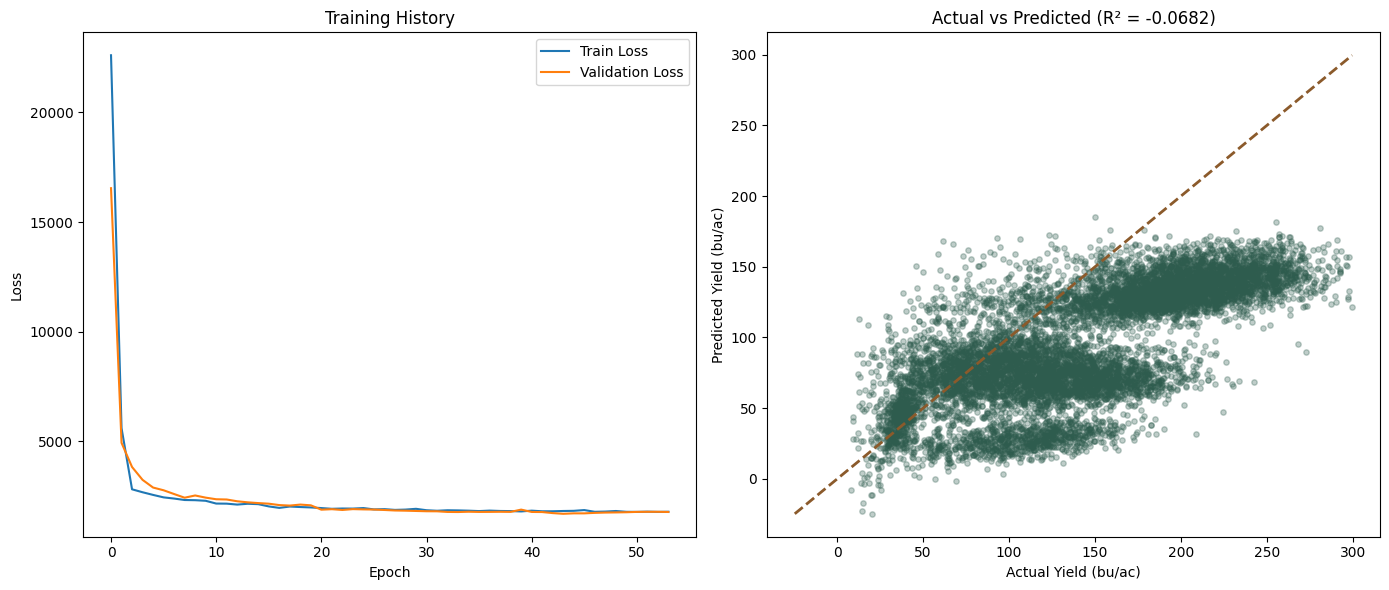


Model Comparison:
                    Model       RMSE        R²
0           Previous LSTM  58.600000  0.131500
1       Interaction Model  61.210000  0.052500
2  Simplified + Agronomic  64.995722 -0.068203


In [50]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# try adding some agronomic features derived from weather seqs instead of the whole big long thing
def add_agronomic_features(weather_sequences, anthesis_days=None):
    new_sequences = []
    window_features_list = []
    
    for i, seq in enumerate(weather_sequences):
        t_max = seq[:, 1]
        t_min = seq[:, 2]
        rain = seq[:, 6]
        
        heat_stress = np.cumsum((t_max > 30).astype(float)).reshape(-1, 1)
        no_rain = (rain < 0.5).astype(float)
        drought_stress = np.cumsum(no_rain).reshape(-1, 1)
        t_avg = (t_max + t_min) / 2
        gdd = np.maximum(0, t_avg - 10).reshape(-1, 1)
        cum_gdd = np.cumsum(gdd).reshape(-1, 1)
        
        new_seq = np.hstack([seq, heat_stress, drought_stress, cum_gdd])
        new_sequences.append(new_seq)
        
        if anthesis_days is not None:
            anthesis_idx = int(anthesis_days[i]) - 1
            start = max(0, anthesis_idx - 7)
            end = min(len(seq), anthesis_idx + 7)
            flowering_window = seq[start:end]
            
            if len(flowering_window) > 0:
                window_feats = np.array([
                    flowering_window[:, 0].mean(),
                    flowering_window[:, 0].max(),
                    flowering_window[:, 6].sum(),
                    flowering_window[:, 4].max(),
                ])
            else:
                window_feats = np.array([0, 0, 0, 0])
            window_features_list.append(window_feats)
    
    if anthesis_days is not None:
        return new_sequences, np.array(window_features_list)
    return new_sequences

anthesis_train = [d['anthesis'] for i, d in enumerate(model_data) if train_mask[i]]
anthesis_test = [d['anthesis'] for i, d in enumerate(model_data) if test_mask[i]]

X_weather_train_aug, window_train = add_agronomic_features(X_weather_train, anthesis_train)
X_weather_test_aug, window_test = add_agronomic_features(X_weather_test, anthesis_test)

X_weather_train_padded = tf.keras.preprocessing.sequence.pad_sequences(
    X_weather_train_aug, maxlen=192, dtype='float32', padding='post', truncating='post'
)
X_weather_test_padded = tf.keras.preprocessing.sequence.pad_sequences(
    X_weather_test_aug, maxlen=192, dtype='float32', padding='post', truncating='post'
)

window_scaler = StandardScaler()
window_train_scaled = window_scaler.fit_transform(window_train)
window_test_scaled = window_scaler.transform(window_test)

#because maybe we're overfitting who knows
def create_simple_model(sequence_length, n_weather_features, n_window_features, n_male, n_female, n_pheno, n_locations, n_years):
    
    weather_in = layers.Input(shape=(sequence_length, n_weather_features), name='weather')
    x = layers.Masking(mask_value=0.)(weather_in)
    x = layers.LSTM(16, dropout=0.2)(x)
    
    window_in = layers.Input(shape=(n_window_features,), name='window_features')
    
    male_in = layers.Input(shape=(1,), name='male')
    male_emb = layers.Embedding(n_male, 4)(male_in)
    male_flat = layers.Flatten()(male_emb)
    
    female_in = layers.Input(shape=(1,), name='female')
    female_emb = layers.Embedding(n_female, 4)(female_in)
    female_flat = layers.Flatten()(female_emb)
    
    location_in = layers.Input(shape=(1,), name='location')
    location_emb = layers.Embedding(n_locations, 4)(location_in)
    location_flat = layers.Flatten()(location_emb)
    
    year_in = layers.Input(shape=(1,), name='year')
    year_emb = layers.Embedding(n_years, 2)(year_in)
    year_flat = layers.Flatten()(year_emb)
    
    pheno_in = layers.Input(shape=(n_pheno,), name='phenotypes')
    
    concat = layers.Concatenate()([x, window_in, male_flat, female_flat, location_flat, year_flat, pheno_in])
    x = layers.Dense(16, activation='relu')(concat)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1)(x)
    
    model = Model(
        inputs=[weather_in, window_in, male_in, female_in, location_in, year_in, pheno_in],
        outputs=out
    )
    return model

model = create_simple_model(
    sequence_length=192,
    n_weather_features=X_weather_train_padded.shape[2],
    n_window_features=4,
    n_male=len(np.unique(X_male_train)),
    n_female=15,
    n_pheno=5,
    n_locations=n_locations,
    n_years=n_years
)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

history = model.fit(
    [X_weather_train_padded, window_train_scaled, X_male_train.reshape(-1,1), 
     X_female_train.reshape(-1,1), location_train.reshape(-1,1), 
     year_train.reshape(-1,1), X_pheno_train],
    y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)

y_pred = model.predict(
    [X_weather_test_padded, window_test_scaled, X_male_test.reshape(-1,1), 
     X_female_test.reshape(-1,1), location_test.reshape(-1,1), 
     year_test.reshape(-1,1), X_pheno_test]
).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n{'='*50}")
print("simplified model with ag features")
print(f"{'='*50}")
print(f"RMSE: {rmse:.2f} bu/ac")
print(f"R²: {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training History')
axes[0].legend()

axes[1].scatter(y_test, y_pred, alpha=0.3, c='#2E5C4E', s=15)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], '--', color='#8B5A2B', linewidth=2)
axes[1].set_xlabel('Actual Yield (bu/ac)')
axes[1].set_ylabel('Predicted Yield (bu/ac)')
axes[1].set_title(f'Actual vs Predicted (R² = {r2:.4f})')

plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'Model': ['First LSTM', 'Interaction Model', 'Simplified + Agronomic'],
    'RMSE': [58.60, 61.21, rmse],
    'R²': [0.1315, 0.0525, r2]
})
print("\nmodel comparison:")
print(comparison)

Loading data...
Adding agronomic features...
Train samples: 12896
Test samples: 9771
Weather features: 11
Window features: 4


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ weather             │ (None, 192, 11)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 192, 11)   │          0 │ weather[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 192, 11)   │          0 │ weather[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 192)       │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ male (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ female (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ location            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ year (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 192, 32)   │      5,632 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ window_features     │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 8)      │        216 │ male[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 8)      │        120 │ female[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 4)      │         60 │ location[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 4)      │         20 │ year[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phenotypes          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 16)        │      3,136 │ lstm[0][0],       │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │         40 │ window_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 11,769 (45.97 KB)

 Trainable params: 11,705 (45.72 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 35s 98ms/step - loss: 25614.9453 - mae: 153.6748 - val_loss: 19309.3066 - val_mae: 128.7579
Epoch 2/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 30s 92ms/step - loss: 21120.7188 - mae: 131.8702 - val_loss: 12714.3770 - val_mae: 100.6914
Epoch 3/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 30s 93ms/step - loss: 18661.9961 - mae: 115.1995 - val_loss: 9300.4727 - val_mae: 83.0422
Epoch 4/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 31s 95ms/step - loss: 17101.5156 - mae: 105.1452 - val_loss: 7183.3521 - val_mae: 70.4170
Epoch 5/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 31s 97ms/step - loss: 15743.3330 - mae: 100.7095 - val_loss: 7482.0854 - val_mae: 71.7927
Epoch 6/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 31s 95ms/step - loss: 13304.6113 - mae: 93.3682 - val_loss: 6525.9326 - val_mae: 67.0564
Epoch 7/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 31s 95ms/step - loss: 11228.8066 - mae: 86.2803 - val_loss: 5919.2119 - val_mae: 64.4740
Epoch 8/100
323/323 ━━━━━━━━━━━━━━━━━━━━ 32s 100ms/step - loss: 9739.7793 - mae: 

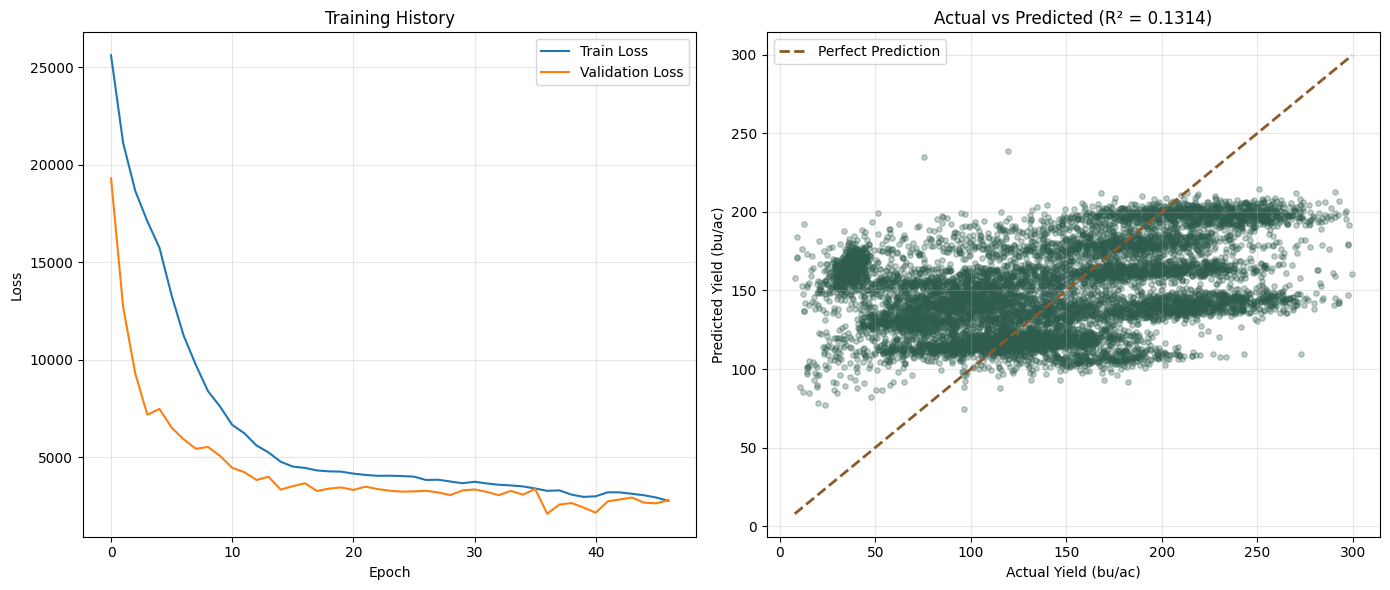


Model Comparison:
                 Model      RMSE        R²
         Previous LSTM 58.600000  0.131500
     Interaction Model 61.210000  0.052500
Simplified + Agronomic 65.000000 -0.068200
    Medium + Agronomic 58.610261  0.131377

✅ Model saved as 'medium_agronomic_model.h5'


In [51]:
# THIS IS THE FINAL MODEL WE LANDED ON IT DOES NOT PERFORM THAT WELL BUT WE TRIED REALLY HARD I THINK WE'RE IN OVER OUR HEADS
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

# try using agronomic features derived from weather data instead of raw weather sequences
def add_agronomic_features(weather_sequences, anthesis_days=None):
    new_sequences = []
    window_features_list = []
    
    for i, seq in enumerate(weather_sequences):
        t_max = seq[:, 1]
        t_min = seq[:, 2]
        rain = seq[:, 6]
        
        heat_stress = np.cumsum((t_max > 30).astype(float)).reshape(-1, 1)
        no_rain = (rain < 0.5).astype(float)
        drought_stress = np.cumsum(no_rain).reshape(-1, 1)
        t_avg = (t_max + t_min) / 2
        gdd = np.maximum(0, t_avg - 10).reshape(-1, 1)
        cum_gdd = np.cumsum(gdd).reshape(-1, 1)
        
        new_seq = np.hstack([seq, heat_stress, drought_stress, cum_gdd])
        new_sequences.append(new_seq)
        
        if anthesis_days is not None:
            anthesis_idx = int(anthesis_days[i]) - 1
            start = max(0, anthesis_idx - 7)
            end = min(len(seq), anthesis_idx + 7)
            flowering_window = seq[start:end]
            
            if len(flowering_window) > 0:
                window_feats = np.array([
                    flowering_window[:, 0].mean(),
                    flowering_window[:, 0].max(),
                    flowering_window[:, 6].sum(),
                    flowering_window[:, 4].max(),
                ])
            else:
                window_feats = np.array([0, 0, 0, 0])
            window_features_list.append(window_feats)
    
    if anthesis_days is not None:
        return new_sequences, np.array(window_features_list)
    return new_sequences

with open('model_ready_data.pkl', 'rb') as f:
    model_data = pickle.load(f)

weather_full = [d['weather_sequence'] for d in model_data]
male_full = np.array([d['male_parent'] for d in model_data])
female_full = np.array([d['female_cluster'] for d in model_data])
pheno_full = np.array([[d['plant_height'], d['ear_height'], d['anthesis'], 
                        d['silking'], d['stand_count']] for d in model_data])
y_full = np.array([d['yield'] for d in model_data])
years_full = np.array([int(d['year']) for d in model_data])
locations_full = [d['location'] for d in model_data]
anthesis_full = np.array([d['anthesis'] for d in model_data])

from sklearn.preprocessing import LabelEncoder
male_encoder = LabelEncoder()
male_enc_full = male_encoder.fit_transform(male_full)
female_enc_full = female_full.astype(int)
pheno_scaler = StandardScaler()
pheno_scaled_full = pheno_scaler.fit_transform(pheno_full)
location_encoder = LabelEncoder()
location_enc_full = location_encoder.fit_transform(locations_full)
year_encoder = LabelEncoder()
year_enc_full = year_encoder.fit_transform(years_full)

train_mask = (years_full >= 2019) & (years_full <= 2021)
test_mask = (years_full >= 2022) & (years_full <= 2023)

X_weather_train = [weather_full[i] for i in range(len(weather_full)) if train_mask[i]]
X_weather_test = [weather_full[i] for i in range(len(weather_full)) if test_mask[i]]
anthesis_train = anthesis_full[train_mask]
anthesis_test = anthesis_full[test_mask]

X_weather_train_aug, window_train = add_agronomic_features(X_weather_train, anthesis_train)
X_weather_test_aug, window_test = add_agronomic_features(X_weather_test, anthesis_test)

X_weather_train_padded = pad_sequences(X_weather_train_aug, maxlen=192, dtype='float32', padding='post', truncating='post')
X_weather_test_padded = pad_sequences(X_weather_test_aug, maxlen=192, dtype='float32', padding='post', truncating='post')

window_scaler = StandardScaler()
window_train_scaled = window_scaler.fit_transform(window_train)
window_test_scaled = window_scaler.transform(window_test)

X_male_train = male_enc_full[train_mask]
X_male_test = male_enc_full[test_mask]
X_female_train = female_enc_full[train_mask]
X_female_test = female_enc_full[test_mask]
X_pheno_train = pheno_scaled_full[train_mask]
X_pheno_test = pheno_scaled_full[test_mask]
location_train = location_enc_full[train_mask]
location_test = location_enc_full[test_mask]
year_train = year_enc_full[train_mask]
year_test = year_enc_full[test_mask]
y_train = y_full[train_mask]
y_test = y_full[test_mask]

n_locations = len(location_encoder.classes_)
n_years = len(year_encoder.classes_)

print(f"Train samples: {len(X_weather_train_padded)}")
print(f"Test samples: {len(X_weather_test_padded)}")
print(f"Weather features: {X_weather_train_padded.shape[2]}")
print(f"Window features: {window_train_scaled.shape[1]}")

def create_medium_model(sequence_length, n_weather_features, n_window_features, n_male, n_female, n_pheno, n_locations, n_years):
    
    weather_in = layers.Input(shape=(sequence_length, n_weather_features), name='weather')
    x = layers.Masking(mask_value=0.)(weather_in)
    x = layers.LSTM(32, return_sequences=True, dropout=0.25)(x)
    x = layers.LSTM(16, dropout=0.25)(x)
    
    window_in = layers.Input(shape=(n_window_features,), name='window_features')
    window_dense = layers.Dense(8, activation='relu')(window_in)
    
    male_in = layers.Input(shape=(1,), name='male')
    male_emb = layers.Embedding(n_male, 8)(male_in)
    male_flat = layers.Flatten()(male_emb)
    
    female_in = layers.Input(shape=(1,), name='female')
    female_emb = layers.Embedding(n_female, 8)(female_in)
    female_flat = layers.Flatten()(female_emb)
    
    location_in = layers.Input(shape=(1,), name='location')
    location_emb = layers.Embedding(n_locations, 4)(location_in)
    location_flat = layers.Flatten()(location_emb)
    
    year_in = layers.Input(shape=(1,), name='year')
    year_emb = layers.Embedding(n_years, 4)(year_in)
    year_flat = layers.Flatten()(year_emb)
    
    pheno_in = layers.Input(shape=(n_pheno,), name='phenotypes')
    pheno_dense = layers.Dense(8, activation='relu')(pheno_in)
    
    concat = layers.Concatenate()([x, window_dense, male_flat, female_flat, location_flat, year_flat, pheno_dense])
    
    x = layers.Dense(32, activation='relu')(concat)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1)(x)
    
    model = Model(
        inputs=[weather_in, window_in, male_in, female_in, location_in, year_in, pheno_in],
        outputs=out
    )
    return model

model = create_medium_model(
    sequence_length=192,
    n_weather_features=X_weather_train_padded.shape[2],
    n_window_features=4,
    n_male=len(np.unique(X_male_train)),
    n_female=15,
    n_pheno=5,
    n_locations=n_locations,
    n_years=n_years
)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

history = model.fit(
    [X_weather_train_padded, window_train_scaled, X_male_train.reshape(-1,1), 
     X_female_train.reshape(-1,1), location_train.reshape(-1,1), 
     year_train.reshape(-1,1), X_pheno_train],
    y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)

y_pred = model.predict(
    [X_weather_test_padded, window_test_scaled, X_male_test.reshape(-1,1), 
     X_female_test.reshape(-1,1), location_test.reshape(-1,1), 
     year_test.reshape(-1,1), X_pheno_test]
).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("med model with ag features")
print(f"RMSE: {rmse:.2f} bu/ac")
print(f"MAE: {mae:.2f} bu/ac")
print(f"R²: {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(history.history['loss'], label='train loss')
axes[0].plot(history.history['val_loss'], label='validation loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].set_title('training history')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred, alpha=0.3, c='#2E5C4E', s=15)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], '--', color='#8B5A2B', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Yield (bu/ac)')
axes[1].set_ylabel('Predicted Yield (bu/ac)')
axes[1].set_title(f'Actual vs Predicted (R² = {r2:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'Model': ['First LSTM', 'Interaction Model', 'Simplified + Agronomic', 'Medium + Agronomic'],
    'RMSE': [58.60, 61.21, 65.00, rmse],
    'R²': [0.1315, 0.0525, -0.0682, r2]
})
print("\nModel Comparison:")
print(comparison.to_string(index=False))

model.save('medium_agronomic_model.h5')
